# 🤖 RL-AutoML: Agente Otimizador de Hiperparâmetros (Q-Learning)

Neste experimento de **MLOps Avançado**, vamos substituir algoritmos clássicos de otimização (como Random Search ou Bayesian Optimization/Optuna) por um **Agente de Inteligência Artificial Autônomo** baseado em *Reinforcement Learning* (Q-Learning).

O Agente aprenderá a navegar no "espaço de hiperparâmetros" de um modelo `LightGBM`. Ele vai testar combinações, observar se a métrica (F1-Score) melhora ou piora, e atualizar sua matriz de conhecimento (Q-Table).

**Dataset:** Breast Cancer (Classificação binária super leve para permitir milhares de rodadas rápidas).
**Ações do Agente:** Aumentar ou Diminuir (Learning Rate, Num Leaves, Max Depth).


In [1]:
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import joblib
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')

# Configurar MLflow local
mlflow.set_tracking_uri("sqlite:///../../mlruns.db")
mlflow.set_experiment("RL_AutoML_QLearning")
plt.style.use('dark_background')


2026/07/29 14:43:35 INFO mlflow.tracking.fluent: Experiment with name 'RL_AutoML_QLearning' does not exist. Creating a new experiment.


## 1. O Ambiente (Hyperparameter Environment)

O ambiente simula as leis físicas do mundo do Agente. É aqui que traduzimos as coordenadas `(0,1,2)` para hiperparâmetros reais, treinamos o modelo e devolvemos a "Recompensa" (Reward).


In [2]:
class HyperparameterEnv:
    def __init__(self):
        # Carregando dados
        data = load_breast_cancer()
        self.X, self.y = data.data, data.target
        
        # Discretização do espaço (5 opções para cada hiperparâmetro)
        self.lr_bins = [0.01, 0.05, 0.1, 0.2, 0.5]
        self.leaves_bins = [7, 15, 31, 63, 127]
        self.depth_bins = [3, 5, 7, 9, 15]
        
        # Limites (0 a 4)
        self.max_idx = 4
        
        self.reset()
        
    def reset(self):
        # Começa no meio do espaço
        self.state = [2, 2, 2] 
        self.best_f1 = 0.0
        self.current_step = 0
        self.max_steps = 15
        return tuple(self.state)
        
    def get_f1_score(self, state):
        lr = self.lr_bins[state[0]]
        leaves = self.leaves_bins[state[1]]
        depth = self.depth_bins[state[2]]
        
        model = lgb.LGBMClassifier(
            learning_rate=lr, 
            num_leaves=leaves, 
            max_depth=depth, 
            n_estimators=50, 
            random_state=42, 
            verbose=-1
        )
        # Retorna a média de F1 em Cross-Validation (3 folds)
        score = cross_val_score(model, self.X, self.y, cv=3, scoring='f1').mean()
        return score

    def step(self, action):
        '''
        Ações:
        0: + LR
        1: - LR
        2: + Leaves
        3: - Leaves
        4: + Depth
        5: - Depth
        '''
        self.current_step += 1
        new_state = list(self.state)
        reward = -0.1 # Penalidade de tempo (para incentivar o agente a ser rápido)
        
        # Aplicar ação
        if action == 0: new_state[0] += 1
        elif action == 1: new_state[0] -= 1
        elif action == 2: new_state[1] += 1
        elif action == 3: new_state[1] -= 1
        elif action == 4: new_state[2] += 1
        elif action == 5: new_state[2] -= 1
        
        # Verificar limites da matriz (paredes do ambiente)
        if any(s < 0 or s > self.max_idx for s in new_state):
            # Agente bateu na parede
            reward = -2.0
            done = self.current_step >= self.max_steps
            return tuple(self.state), reward, done, self.best_f1
            
        # Avaliar novo estado
        self.state = new_state
        current_f1 = self.get_f1_score(self.state)
        
        # Sistema de Recompensa Principal
        if current_f1 > self.best_f1:
            # Recompensa proporcional ao ganho absoluto
            reward += (current_f1 - self.best_f1) * 100.0
            self.best_f1 = current_f1
        else:
            # Penalidade se a métrica não melhorar
            reward -= 0.5
            
        # Condição de vitória ou timeout
        done = self.current_step >= self.max_steps or self.best_f1 > 0.975
        
        if self.best_f1 > 0.975:
            reward += 10.0 # Bônus de vitória
            done = True
            
        return tuple(self.state), reward, done, current_f1


## 2. O Agente (Q-Learning)

O agente armazena o conhecimento em uma Tabela Q (Q-Table), inicializada com zeros. A cada passo, ele usa a **Equação de Bellman** para atualizar o valor da ação que ele tomou, baseado na recompensa futura esperada. 
A tática `Epsilon-Greedy` garante que no começo ele explore aleatoriamente (Epsilon alto), e com o passar dos episódios passe a explotar a matriz (Epsilon baixo).


In [3]:
class QLearningAgent:
    def __init__(self, state_space_shape, action_space_size, alpha=0.1, gamma=0.9, epsilon=1.0, epsilon_decay=0.99):
        # Inicializa a Q-Table: (5, 5, 5, 6)
        self.q_table = np.zeros(state_space_shape + (action_space_size,))
        self.alpha = alpha       # Taxa de aprendizado
        self.gamma = gamma       # Fator de desconto (visão de futuro)
        self.epsilon = epsilon   # Taxa de exploração (aleatoriedade)
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = 0.05
        self.action_space_size = action_space_size

    def choose_action(self, state):
        if np.random.uniform(0, 1) < self.epsilon:
            # Explorar: Ação aleatória
            return np.random.randint(self.action_space_size)
        else:
            # Explotar: Melhor ação da Tabela Q
            return np.argmax(self.q_table[state])

    def update_q_table(self, state, action, reward, next_state):
        # Equação de Bellman
        best_next_action = np.argmax(self.q_table[next_state])
        td_target = reward + self.gamma * self.q_table[next_state][best_next_action]
        td_error = td_target - self.q_table[state][action]
        
        # Atualiza o valor
        self.q_table[state][action] += self.alpha * td_error

    def decay_epsilon(self):
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay


## 3. Loop de Treinamento e Integração MLOps

Vamos treinar o agente por 150 episódios. Tudo será logado no MLflow, mostrando como a IA evolui de tentar configurações aleatórias idiotas para mirar a laser no melhor hyperparâmetro!


In [4]:
env = HyperparameterEnv()
agent = QLearningAgent(state_space_shape=(5, 5, 5), action_space_size=6)

episodes = 150
rewards_history = []
f1_history = []

with mlflow.start_run(run_name="RL_Agent_Training"):
    mlflow.set_tag("algorithm", "Q-Learning")
    mlflow.set_tag("task", "AutoML-Hyperparameter-Tuning")
    
    for episode in range(episodes):
        state = env.reset()
        total_reward = 0
        best_f1_episode = 0
        done = False
        
        while not done:
            action = agent.choose_action(state)
            next_state, reward, done, current_f1 = env.step(action)
            
            agent.update_q_table(state, action, reward, next_state)
            
            state = next_state
            total_reward += reward
            if current_f1 > best_f1_episode:
                best_f1_episode = current_f1
                
        agent.decay_epsilon()
        rewards_history.append(total_reward)
        f1_history.append(best_f1_episode)
        
        # Logando métricas de cada episódio
        mlflow.log_metric("Episode_Reward", total_reward, step=episode)
        mlflow.log_metric("Episode_Best_F1", best_f1_episode, step=episode)
        mlflow.log_metric("Epsilon", agent.epsilon, step=episode)
        
        if episode % 25 == 0 or episode == episodes - 1:
            print(f"Episode {episode}: Total Reward = {total_reward:.2f} | Best F1 = {best_f1_episode:.4f} | Epsilon = {agent.epsilon:.2f}")

    print("Treinamento finalizado!")
    
    # Salvar a Tabela Q como artefato no MLOps
    np.save('q_table_final.npy', agent.q_table)
    mlflow.log_artifact('q_table_final.npy')


Episode 0: Total Reward = 100.22 | Best F1 = 0.9762 | Epsilon = 0.99


Episode 25: Total Reward = 107.34 | Best F1 = 0.9764 | Epsilon = 0.77


Episode 50: Total Reward = 89.43 | Best F1 = 0.9693 | Epsilon = 0.60


Episode 75: Total Reward = 86.63 | Best F1 = 0.9693 | Epsilon = 0.47


Episode 100: Total Reward = 88.93 | Best F1 = 0.9693 | Epsilon = 0.36


Episode 125: Total Reward = 90.21 | Best F1 = 0.9721 | Epsilon = 0.28


Episode 149: Total Reward = 102.07 | Best F1 = 0.9777 | Epsilon = 0.22
Treinamento finalizado!


## 4. Analisando o Cérebro do Agente (Gráficos)

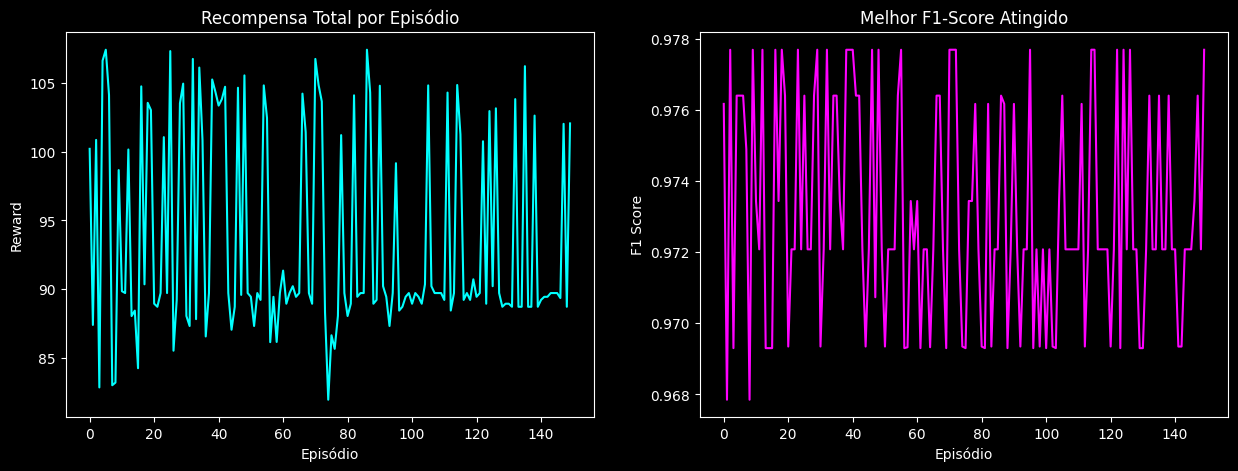

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Recompensa (Aprendizado)
ax[0].plot(rewards_history, color='cyan')
ax[0].set_title('Recompensa Total por Episódio')
ax[0].set_xlabel('Episódio')
ax[0].set_ylabel('Reward')

# Plot 2: Melhor F1 Score
ax[1].plot(f1_history, color='magenta')
ax[1].set_title('Melhor F1-Score Atingido')
ax[1].set_xlabel('Episódio')
ax[1].set_ylabel('F1 Score')

plt.savefig('rl_learning_curve.png')
plt.show()
